# Lezione 10 — Applicazione in Python: rischio di credito

## Caso Aula: China Evergrande 2021: crisi immobiliare, dipendenza sistemica e controllo della concentrazione creditizia

---

### 1. Sintesi del Caso

* **Contesto:** Estate 2021, fase di forte deterioramento delle condizioni finanziarie del settore immobiliare cinese e del merito creditizio di China Evergrande Group.
* **Domanda quantitativa:** Quale distribuzione della perdita a un anno produce il portafoglio e come cambiano perdita attesa, dispersione, VaR e CVaR se viene introdotto un limite del 10% alla concentrazione verso un singolo debitore, riducendo l'investimento in Evergrande e riallocando la quota liberata verso posizioni inizialmente BBB e BB?
* **Variabile finale:** Distribuzione empirica della perdita a un anno del portafoglio $L^P$, stime delle relative misure di rischio (perdita media, varianza, deviazione standard, VaR e CVaR al 95% e 99%) e confronto tra la configurazione iniziale e quella soggetta a limite di concentrazione.
* **Informazione disponibile:**
  * Portafoglio creditizio composto da 36 debitori suddivisi per rating iniziale (BBB, BB, B, CCC) con investimento totale pari a $V_0^P = 200$ milioni di USD.
  * Processo di regime sistemico a 3 stati $M_t \in \{N, S, C\}$ governed da una catena di Markov con matrice di transizione $Q$ e stato iniziale $M_0 = S$.
  * Matrici di migrazione creditizia trimestre per trimestre dipendenti dal regime sistemico: $P^{(N)}$, $P^{(S)}$, $P^{(C)}$ per lo spazio degli stati $\mathcal{I} = \{BBB, BB, B, CCC, D\}$, con stato $D$ assorbente.
  * Tassi di perdita migration-based $\ell(X_{i,0}, X_{i,4})$ per i debitori non in default a fine anno ($T=4$).
  * LGD stocastica dipendente dal regime sistemico al tempo di default: $\operatorname{LGD}^{(N)} = 0.55$, $\operatorname{LGD}^{(S)} = 0.70$, $\operatorname{LGD}^{(C)} = 0.85$.
  * Specifiche di simulazione: $N_{\mathrm{MC}} = 50\,000$ repliche Monte Carlo, orizzonte temporale $T = 4$ trimestri, seed $2027$.

---

### 2. Quantità da stimare o calcolare

Per ciascuno dei due portafogli (iniziale e soggetto al limite):

1. Perdita media:
$$
\mathbb{E}[L^P]
$$

2. Varianza della perdita:
$$
\operatorname{Var}(L^P)
$$

3. Deviazione standard della perdita:
$$
\sigma(L^P)
$$

4. Value at Risk ai livelli 95% e 99%:
$$
\operatorname{VaR}_{0.95}(L^P), \qquad \operatorname{VaR}_{0.99}(L^P)
$$

5. Conditional Value at Risk ai livelli 95% e 99%:
$$
\operatorname{CVaR}_{0.95}(L^P), \qquad \operatorname{CVaR}_{0.99}(L^P)
$$

Ulteriori quantità da stimare:

6. Probabilità simulata che il regime $C$ venga raggiunto almeno una volta durante l'orizzonte di 4 trimestri.

7. Numero medio di default nel portafoglio nell'orizzonte considerato.

8. Perdita media del portafoglio iniziale condizionata:
   * agli scenari nei quali il regime $C$ viene raggiunto almeno una volta;
   * agli scenari nei quali il regime $C$ non viene mai raggiunto.

9. Variazione puntuale di ciascuna misura di rischio $\rho$:
$$
\Delta\rho = \rho(L_{\mathrm{lim}}^P) - \rho(L_{\mathrm{base}}^P)
$$

10. Differenza della perdita realizzata scenario per scenario tra le due configurazioni di portafoglio:
$$
\Delta L^{(r)} = L_{\mathrm{lim}}^{P,(r)} - L_{\mathrm{base}}^{P,(r)}
$$

---

### 3. Output richiesti

#### 3.1 Risultati numerici
* Indicatori sintetici di rischio per entrambi i portafogli: perdita media, varianza, deviazione standard, VaR 95%, CVaR 95%, VaR 99%, CVaR 99%.
* Distribuzione empirica della perdita del portafoglio iniziale $L_{\mathrm{base}}^P$.
* Distribuzione empirica della perdita del portafoglio soggetto al limite $L_{\mathrm{lim}}^P$.
* Distribuzione empirica delle differenze di perdita scenario per scenario $\Delta L^{(r)}$.
* Probabilità simulata di ingresso nel regime $C$.
* Numero medio di default complessivi.
* Perdita media negli scenari con e senza ingresso nel regime $C$.
* Differenze tra le misure di rischio dei due portafogli ($\Delta\rho$).
* Valutazione dell'incidenza della politica di concentrazione sulle misure di coda.

#### 3.2 Tabelle
* **Tabella 1 — Portafoglio iniziale:** Composizione per rating, numero di debitori, investimento individuale e investimento complessivo.
* **Tabella 2 — Portafoglio soggetto al limite:** Composizione del portafoglio dopo la riduzione della posizione Evergrande e la riallocazione dell'investimento.
* **Tabella 3 — Misure di rischio:** Confronto tra portafoglio iniziale, portafoglio soggetto al limite e differenza tra le rispettive misure.
* **Tabella 4 — Regime sistemico e perdita:** Confronto, per il portafoglio iniziale, tra scenari con e senza ingresso nello stato $C$.

#### 3.3 Grafici
* **Figura 1 — Distribuzione della perdita del portafoglio iniziale:** Istogramma e densità empirica di $L_{\mathrm{base}}^P$ con indicazione grafica di VaR 95% e VaR 99%.
* **Figura 2 — Confronto delle code:** Confronto sovrapposto delle distribuzioni delle perdite del portafoglio iniziale e del portafoglio soggetto al limite, con focus sulla coda destra.
* **Figura 3 — Regime sistemico e perdita:** Confronto della distribuzione delle perdite del portafoglio iniziale condizionata all'ingresso vs. non ingresso nel regime di crisi $C$.

---

### 4. Controlli richiesti

1. Verifica che ogni riga della matrice di transizione di regime $Q$ sommi a 1.
2. Verifica che ogni riga delle matrici di migrazione creditizia $P^{(N)}$, $P^{(S)}$ e $P^{(C)}$ sommi a 1.
3. Verifica che lo stato di default $D$ risulti assorbente in tutte le matrici di migrazione creditizia.
4. Verifica che il regime sistemico iniziale sia $M_0 = S$ in ogni replica Monte Carlo.
5. Verifica che all'interno della stessa replica esista una sola traiettoria sistemica, comune a tutti i 36 debitori.
6. Verifica che, condizionatamente alla traiettoria di regime comune, le estrazioni stocastiche per le migrazioni dei debitori siano indipendenti.
7. Verifica che il tempo di default $\tau_i$ coincida esattamente con il primo trimestre di ingresso nello stato $D$.
8. Verifica che la LGD applicata in caso di default corrisponda al regime sistemico $M_{\tau_i - 1}$ che governa la transizione verso $D$.
9. Verifica che un debitore entrato nello stato $D$ non possa successivamente uscire dal default.
10. Verifica che la funzione di perdita migration-based $\ell$ sia applicata unicamente ai debitori che non sono entrati in default ($\tau_i > 4$).
11. Verifica che l'investimento complessivo $V_0^P$ sia pari a 200 milioni di USD in entrambi i portafogli.
12. Verifica che nel portafoglio soggetto al limite:
    * la posizione Evergrande sia pari a 20 milioni di USD;
    * vengano riallocati esattamente 10 milioni di USD;
    * la riallocazione interessi esclusivamente i gruppi BBB e BB;
    * sia mantenuta la proporzione relativa originale tra gli investimenti dei gruppi BBB e BB.
13. Verifica che il confronto tra portafoglio iniziale e soggetto al limite utilizzi rigorosamente le medesime traiettorie sistemiche e creditizie simulate.
14. Verifica che la perdita aggregata di portafoglio coincida con la somma delle perdite dei singoli debitori.
15. Verifica la riproducibilità esatta dei risultati numerici impostando il seed $2027$.
16. Verifica della stabilità delle stime delle principali misure di rischio all'aumentare delle simulazioni Monte Carlo.
17. Verifica che VaR e CVaR siano calcolati direttamente sulle distribuzioni delle perdite monetarie dei due portafogli.

---

### 5. Nota di Vincolo Specifica

La Scheda Caso costituisce la **specifica vincolante del lavoro** e non deve essere modificata in alcuna sua parte nel corso dell'analisi.

## Flusso Logico-Teorico Risolutivo (6 Tappe)

Il problema quantitativo viene risolto strutturando l'analisi in 6 tappe logico-teoriche sequenziali, le quali garantiscono la piena tracciabilità dei modelli, delle metriche e dei controlli definiti nella Scheda Caso:

| Tappa | Denominazione Tappa | Contenuto Teorico e Formule Coinvolte | Output / Controlli Collegati |
|---:|---|---|---|
| **1** | **Definizione della Struttura di Portafoglio e Politica di Concentrazione** | Formalizzazione dei portafogli base e limitato ($V_0^P = 200\text{M}\$$). Regola di riallocazione dei $10\text{M}\$$ eccedenti da Evergrande verso i gruppi BBB e BB:<br>$V_{i,0}^{\text{lim}} = V_{i,0}^{\text{base}} + \Delta V_E \cdot \frac{V_{i,0}^{\text{base}}}{\sum_{j \in \text{BBB,BB}} V_{j,0}^{\text{base}}}$ | **Tabelle 1 e 2**<br>Controlli 11, 12 |
| **2** | **Simulazione della Traiettoria di Regime Sistemico** | Modellizzazione della Catena di Markov a 3 stati $M_t \in \{N,S,C\}$ con stato iniziale $M_0 = S$ e matrice di transizione $Q$:<br>$\Pr(M_{t+1}=j \mid M_t=i) = Q_{ij}$ su $T=4$ trimestri per $N_{\mathrm{MC}}=50\,000$ repliche. | **Probabilità di ingresso in $C$**<br>Controlli 1, 4, 15 |
| **3** | **Simulazione delle Migrazioni Creditizie e Indipendenza Condizionata** | Evoluzione del rating $X_{i,t} \in \mathcal{I}$ guidata dalla matrice $P^{(M_t)}$ attiva al tempo $t$. Indipendenza stocastica condizionata tra debitori dati i regimi comuni. Riconoscimento dello stato $D$ come assorbente. | Controlli 2, 3, 5, 6, 9 |
| **4** | **Determinazione del Tempo di Default e Valutazione delle Perdite Individuali** | Identificazione dello stopping time $\tau_i = \min \{t \le 4 : X_{i,t} = D\}$. Struttura di perdita individuale bivariata ($\operatorname{EAD}_i = V_{i,0}$):<br>$L_i = \begin{cases} V_{i,0} \cdot \ell(X_{i,0}, X_{i,4}) & \text{se } \tau_i > 4 \\ V_{i,0} \cdot \operatorname{LGD}^{(M_{\tau_i - 1})} & \text{se } \tau_i \le 4 \end{cases}$ | **Numero medio di default**<br>Controlli 7, 8, 10 |
| **5** | **Aggregazione di Portafoglio e Generazione delle Distribuzioni Monte Carlo** | Calcolo della perdita totale $L^P = \sum_{i=1}^{36} L_i$ sotto il principio dei *Common Random Numbers* (stesse traiettorie per entrambi i portafogli). Estrazione di $L_{\mathrm{base}}^P$, $L_{\mathrm{lim}}^P$ e della differenza $\Delta L^{(r)}$. | **Distribuzioni empiriche**<br>Controlli 13, 14, 16 |
| **6** | **Stima delle Misure di Rischio e Analisi Condizionata di Coda** | Calcolo di $\mathbb{E}[L^P]$, $\operatorname{Var}(L^P)$, $\sigma(L^P)$, $\operatorname{VaR}_\alpha$ e $\operatorname{CVaR}_\alpha$ ($\alpha \in \{0.95, 0.99\}$). Valutazione delle variazioni $\Delta\rho$ e analisi condizionata all'ingresso nel regime di crisi $C$. | **Tabelle 3 e 4**<br>**Figure 1, 2 e 3**<br>Controllo 17 |

## Scomposizione Operativa del Notebook in Tappe Input-Output

Per rendere il problema computazionalmente tracciabile e verificabile, l'implementazione in Python viene suddivisa in 6 tappe operative consequenziali. La seguente tabella definisce la catena degli input, delle operazioni, degli output generati, dei controlli da effettuare e della destinazione dei risultati per ciascuna tappa:

| Tappa | Input | Operazione | Output | Controllo | Uso successivo |
|---:|---|---|---|---|---|
| **1** | Parameters e strutture dati della Scheda Caso (sez. 4). | Inizializzazione dei dati in strutture NumPy/Pandas: matrici di transizione $Q, P^{(N)}, P^{(S)}, P^{(C)}$, matrice di perdita non-default $\ell$, vettore $\text{LGD}$, parametri di simulazione ($N_{\text{MC}}=50\,000$, $T=4$, seed=$2027$). | Strutture dati native Python/NumPy/Pandas contenenti la calibrazione vincolante. | **Controlli 1, 2, 3:** Righe delle matrici $Q$ e $P^{(m)}$ sommano a $1.0$; lo stato $D$ è assorbente in tutte le matrici. | Input per la Tappa 2 e per i moduli di simulazione (Tappe 3 e 4). |
| **2** | Portafoglio iniziale e regola di concentrazione (limite $10\%$, pari a max $20\text{M}\$$ per debitore). | Definizione della tabella del **Portafoglio Iniziale** e applicazione della regola di riallocazione dei $10\text{M}\$$ liberati da Evergrande a favore dei gruppi BBB e BB (proporzionale) per il **Portafoglio Limite**. | **Tabella 1** (Portafoglio iniziale) e **Tabella 2** (Portafoglio soggetto al limite). Vettori degli investimenti $V_{\text{base}}$ e $V_{\text{lim}}$ ($36 \times 1$). | **Controlli 11, 12:** Investimento totale = $200\text{M}\$$ per entrambi i portafogli; Evergrande a $20\text{M}\$$ nel portafoglio limite; proporzioni BBB/BB mantenute. | Input vettoriale di capitale per la Tappa 4 (calcolo delle perdite monetarie). |
| **3** | Seed ($2027$), $N_{\text{MC}}$, $T=4$, stato iniziale $M_0=S$, matrici $Q, P^{(N)}, P^{(S)}, P^{(C)}$. | Simulazione Monte Carlo per $N_{\text{MC}}$ repliche: 1) estrazione traiettoria di regime $\{M_t\}_{t=0}^3$; 2) estrazione indipendente del rating $\{X_{i,t}\}_{t=0}^4$ per ciascuno dei 36 debitori guidata da $P^{(M_t)}$. Registrazione dello stato di default e del tempo di primo ingresso $\tau_i$. | Matrice dei regimi $M$ ($N_{\text{MC}} \times 4$), tensor delle traiettorie di rating $X$ ($N_{\text{MC}} \times 36 \times 5$), matrice dei tempi di default $\tau$ ($N_{\text{MC}} \times 36$). | **Controlli 4, 5, 6, 7, 9, 15:** $M_0=S$ in ogni replica; regime unico per replica; migrazioni indipendenti dato il regime; $\tau_i$ al primo ingresso in $D$; assorbimento in $D$; riproducibilità via seed. | Input per la Tappa 4 (valutazione della perdita e del numero di default). |
| **4** | Traiettorie $M$, $X$, $\tau$ (Tappa 3), vettori $V_{\text{base}}, V_{\text{lim}}$ (Tappa 2), matrice $\ell$ e vettori $\text{LGD}$. | Valutazione della perdita per ogni debitore $i$ e replica $r$: $L_{i,r} = V_{i,0} \cdot \operatorname{LGD}^{(M_{\tau_i-1})}$ se $\tau_i \le 4$, oppure $L_{i,r} = V_{i,0} \cdot \ell(X_{i,0}, X_{i,4})$ se $\tau_i > 4$. Aggregazione su portafoglio: $L^P = \sum_i L_i$ per entrambi i portafogli sotto *Common Random Numbers*. | Vettori delle perdite simulate $L_{\text{base}}^P$ e $L_{\text{lim}}^P$ ($N_{\text{MC}} \times 1$), vettori delle differenze $\Delta L^{(r)}$, e conteggio dei default per replica. | **Controlli 8, 10, 13, 14:** LGD basata sul regime al tempo $\tau_i-1$; $\ell$ usata solo se $\tau_i>4$; $L^P = \sum L_i$; stesse traiettorie per entrambi i portafogli. | Input per le Tappe 5 e 6 (stima delle metriche di rischio e visualizzazione). |
| **5** | Vettori delle perdite $L_{\text{base}}^P, L_{\text{lim}}^P, \Delta L^{(r)}$ (Tappa 4), matrice dei regimi $M$ (Tappa 3). | Calcolo delle statistiche descrittive (media, varianza, dev. std), dei quantili ($\text{VaR}_{0.95}, \text{VaR}_{0.99}$) e dei valori attesi condizionati ($\text{CVaR}_{0.95}, \text{CVaR}_{0.99}$). Calcolo della probabilità di ingresso nel regime $C$, del numero medio di default e delle perdite medie condizionate agli scenari con/senza regime $C$. | **Tabella 3** (Misure di rischio e variazioni $\Delta\rho$) e **Tabella 4** (Regime sistemico e perdite condizionate). Stime di probabilità e media dei default. | **Controlli 16, 17:** VaR e CVaR calcolati su perdite monetarie; stabilità delle stime e coerenza delle metriche di coda ($\text{CVaR} \ge \text{VaR}$). | Input per la Tappa 6 (rappresentazione grafica e commento critico). |
| **6** | Vettori delle perdite, differenze $\Delta L^{(r)}$, indicatori di crisi e tabelle sintetici (Tappa 5). | Generazione delle figure richieste: istogramma/densità di $L_{\text{base}}^P$ con VaR (Fig. 1), confronto sovrapposto delle code destre tra portafogli (Fig. 2), confronto densità condizionata a regime $C$ vs no-$C$ (Fig. 3). Esecuzione della ricognizione complessiva dei controlli. | **Figura 1**, **Figura 2**, **Figura 3** e report di sintesi dei controlli di validazione effettuati. | Verifiche visive di coerenza: code destre, ordinamento dei VaR/CVaR, impatto grafico del limite di concentrazione. | Soluzione completa del caso per l'interpretazione critica finale (Fasi 8 e 9). |

## Tappa 1 — Definizione dei Parametri e Controlli sulle Matrici

In questa tappa vengono inizializzate le strutture dati contenenti i parametri vincolanti del modello (matrice di regime $Q$, matrici di migrazione creditizia $P^{(N)}, P^{(S)}, P^{(C)}$, matrice dei tassi di perdita $\ell$, e tassi LGD) e vengono eseguiti i **Controlli 1, 2 e 3** definiti nella Scheda Caso.

In [3]:
import numpy as np
import pandas as pd

# ==========================================
# 1. PARAMETRI GENERALI E DI SIMULAZIONE
# ==========================================
SEED = 2027
N_MC = 50_000
HORIZON_QUARTERS = 4

# Nomi degli stati
SYSTEM_STATES = ['N', 'S', 'C']
RATING_STATES = ['BBB', 'BB', 'B', 'CCC', 'D']

# ==========================================
# 2. MATRICE DI REGIME SISTEMICO (Q)
# Order: (N, S, C)
# ==========================================
Q = np.array([
    [0.84, 0.15, 0.01],
    [0.20, 0.62, 0.18],
    [0.08, 0.30, 0.62]
], dtype=np.float64)

# ==========================================
# 3. MATRICI DI MIGRAZIONE CREDITIZIA (P_N, P_S, P_C)
# Order: (BBB, BB, B, CCC, D)
# ==========================================
P_N = np.array([
    [0.955, 0.038, 0.005, 0.001, 0.001],
    [0.025, 0.925, 0.038, 0.009, 0.003],
    [0.005, 0.035, 0.885, 0.060, 0.015],
    [0.001, 0.004, 0.025, 0.900, 0.070],
    [0.000, 0.000, 0.000, 0.000, 1.000]
], dtype=np.float64)

P_S = np.array([
    [0.925, 0.060, 0.011, 0.003, 0.001],
    [0.012, 0.875, 0.085, 0.022, 0.006],
    [0.003, 0.020, 0.810, 0.135, 0.032],
    [0.000, 0.003, 0.022, 0.855, 0.120],
    [0.000, 0.000, 0.000, 0.000, 1.000]
], dtype=np.float64)

P_C = np.array([
    [0.830, 0.115, 0.035, 0.015, 0.005],
    [0.004, 0.745, 0.145, 0.075, 0.031],
    [0.000, 0.008, 0.650, 0.242, 0.100],
    [0.000, 0.000, 0.008, 0.692, 0.300],
    [0.000, 0.000, 0.000, 0.000, 1.000]
], dtype=np.float64)

# Dizionario matrici per accesso dinamico
P_REGIME = {
    0: P_N,  # N
    1: P_S,  # S
    2: P_C   # C
}

# ==========================================
# 4. FUNZIONE DI PERDITA MIGRATION-BASED (l_matrix)
# Righe = Rating Iniziale, Colonne = Rating Finale (BBB, BB, B, CCC)
# ==========================================
l_matrix = np.array([
    [ 0.00,  0.04,  0.11,  0.26],  # BBB
    [-0.03,  0.00,  0.07,  0.19],  # BB
    [-0.07, -0.04,  0.00,  0.13],  # B
    [-0.12, -0.08, -0.04,  0.00]   # CCC
], dtype=np.float64)

# ==========================================
# 5. LGD PER REGIME SISTEMICO
# N -> 0.55, S -> 0.70, C -> 0.85
# ==========================================
LGD_VEC = np.array([0.55, 0.70, 0.85], dtype=np.float64)

# ==========================================
# CONTROLLI DI VALIDAZIONE (CONTROLLI 1, 2, 3)
# ==========================================
print("=== VERIFICA CONTROLLI TAPPA 1 ===")

# Controllo 1: Somma righe Q == 1.0
q_row_sums = Q.sum(axis=1)
ctrl_1 = np.allclose(q_row_sums, 1.0)
print(f"Controllo 1 - Righe di Q sommano a 1.0: {ctrl_1} (Valori: {q_row_sums})")

# Controllo 2: Somma righe P^(N), P^(S), P^(C) == 1.0
pn_sums = P_N.sum(axis=1)
ps_sums = P_S.sum(axis=1)
pc_sums = P_C.sum(axis=1)
ctrl_2 = np.allclose(pn_sums, 1.0) and np.allclose(ps_sums, 1.0) and np.allclose(pc_sums, 1.0)
print(f"Controllo 2 - Righe di P^(N), P^(S), P^(C) sommano a 1.0: {ctrl_2}")

# Controllo 3: Stato D (indice 4) assorbente in tutte le matrici
d_absorb_N = (P_N[4, 4] == 1.0) and np.all(P_N[4, :4] == 0.0)
d_absorb_S = (P_S[4, 4] == 1.0) and np.all(P_S[4, :4] == 0.0)
d_absorb_C = (P_C[4, 4] == 1.0) and np.all(P_C[4, :4] == 0.0)
ctrl_3 = d_absorb_N and d_absorb_S and d_absorb_C
print(f"Controllo 3 - Stato D assorbente in tutte le matrici: {ctrl_3}")

assert ctrl_1 and ctrl_2 and ctrl_3, "ERRORE: Uno o più controlli teorici sulle matrici non sono soddisfatti!"
print("\n>>> Tappa 1 completata con successo: tutti i controlli sulle matrici sono verificati.")

=== VERIFICA CONTROLLI TAPPA 1 ===
Controllo 1 - Righe di Q sommano a 1.0: True (Valori: [1. 1. 1.])
Controllo 2 - Righe di P^(N), P^(S), P^(C) sommano a 1.0: True
Controllo 3 - Stato D assorbente in tutte le matrici: True

>>> Tappa 1 completata con successo: tutti i controlli sulle matrici sono verificati.


## Tappa 2 — Struttura dei Portafogli e Politica di Concentrazione

In questa tappa definiamo la struttura vettoriale del **Portafoglio Iniziale** e applichiamo la politica di controllo della concentrazione per costruire il **Portafoglio Soggetto al Limite**. La quota di $10$ milioni di dollari liberata dalla riduzione della posizione Evergrande (da $30$M$ a $20$M$) viene redistribuita tra i debitori inizialmente classificati BBB e BB, in proporzione ai loro investimenti iniziali. Vengono generati gli output della **Tabella 1** e della **Tabella 2** ed eseguiti i **Controlli 11 e 12**.

In [4]:
# ==========================================
# 1. DEFINIZIONE DEL PORTAFOGLIO INIZIALE (BASE)
# ==========================================
# Creazione dell'elenco dettagliato dei 36 debitori
debtors_info = []

# 1 Debitore: China Evergrande Group (Rating: B, Investimento: 30M$)
debtors_info.append({'Debitore_ID': 0, 'Gruppo': 'China Evergrande Group', 'Rating_0': 'B', 'Rating_0_idx': 2, 'V_base': 30.0})

# 10 Debitori BBB (Investimento: 6M$ ciascuno)
for i in range(10):
    debtors_info.append({'Debitore_ID': len(debtors_info), 'Gruppo': 'Debitori BBB', 'Rating_0': 'BBB', 'Rating_0_idx': 0, 'V_base': 6.0})

# 10 Debitori BB (Investimento: 5M$ ciascuno)
for i in range(10):
    debtors_info.append({'Debitore_ID': len(debtors_info), 'Gruppo': 'Debitori BB', 'Rating_0': 'BB', 'Rating_0_idx': 1, 'V_base': 5.0})

# 10 Altri debitori B (Investimento: 4M$ ciascuno)
for i in range(10):
    debtors_info.append({'Debitore_ID': len(debtors_info), 'Gruppo': 'Altri debitori B', 'Rating_0': 'B', 'Rating_0_idx': 2, 'V_base': 4.0})

# 5 Debitori CCC (Investimento: 4M$ ciascuno)
for i in range(5):
    debtors_info.append({'Debitore_ID': len(debtors_info), 'Gruppo': 'Debitori CCC', 'Rating_0': 'CCC', 'Rating_0_idx': 3, 'V_base': 4.0})

df_portfolio = pd.DataFrame(debtors_info)

# ==========================================
# 2. APPLICAZIONE POLITICA DI CONCENTRAZIONE (PORTAFOGLIO LIMITE)
# ==========================================
# Riduzione della posizione Evergrande da 30M$ a 20M$ (limite 10% di 200M$)
V_evergrande_base = 30.0
V_evergrande_lim = 20.0
delta_V_reallocate = V_evergrande_base - V_evergrande_lim # 10M$

# Totale iniziale investimento gruppi BBB e BB
total_base_BBB_BB = df_portfolio[df_portfolio['Rating_0'].isin(['BBB', 'BB'])]['V_base'].sum() # 60 + 50 = 110M$

# Calcolo del nuovo investimento per ciascun debitore
V_lim_list = []
for idx, row in df_portfolio.iterrows():
    if row['Gruppo'] == 'China Evergrande Group':
        V_lim_list.append(V_evergrande_lim)
    elif row['Rating_0'] in ['BBB', 'BB']:
        # Riallocazione proporzionale
        alloc_share = row['V_base'] / total_base_BBB_BB
        V_lim_list.append(row['V_base'] + delta_V_reallocate * alloc_share)
    else:
        # Altri debitori B e CCC restano invariati
        V_lim_list.append(row['V_base'])

df_portfolio['V_lim'] = V_lim_list

# Vettori NumPy utili per i calcoli successivi
V_base_vec = df_portfolio['V_base'].to_numpy(dtype=np.float64)
V_lim_vec = df_portfolio['V_lim'].to_numpy(dtype=np.float64)
initial_rating_idx = df_portfolio['Rating_0_idx'].to_numpy(dtype=np.int64)

# ==========================================
# 3. GENERAZIONE TABELLA 1 E TABELLA 2
# ==========================================
def build_summary_table(df, col_v_ind, col_v_tot):
    summary = df.groupby(['Gruppo', 'Rating_0'], sort=False).agg(
        Num_debitori=('Debitore_ID', 'count'),
        Investimento_indiv=(col_v_ind, 'first'),
        Investimento_totale=(col_v_tot, 'sum')
    ).reset_index()
    
    # Riga Totale
    tot_row = pd.DataFrame({
        'Gruppo': ['Totale'],
        'Rating_0': ['-'],
        'Num_debitori': [summary['Num_debitori'].sum()],
        'Investimento_indiv': [np.nan],
        'Investimento_totale': [summary['Investimento_totale'].sum()]
    })
    return pd.concat([summary, tot_row], ignore_index=True)

tabella_1 = build_summary_table(df_portfolio, 'V_base', 'V_base')
tabella_2 = build_summary_table(df_portfolio, 'V_lim', 'V_lim')

print("=== TABELLA 1: PORTAFOGLIO INIZIALE ===")
print(tabella_1.to_string(index=False))

print("\n=== TABELLA 2: PORTAFOGLIO SOGGETTO AL LIMITE ===")
print(tabella_2.to_string(index=False))

# ==========================================
# CONTROLLI DI VALIDAZIONE (CONTROLLI 11, 12)
# ==========================================
print("\n=== VERIFICA CONTROLLI TAPPA 2 ===")

# Controllo 11: Investimento complessivo pari a 200M$ in entrambi i portafogli
sum_v_base = V_base_vec.sum()
sum_v_lim = V_lim_vec.sum()
ctrl_11 = np.isclose(sum_v_base, 200.0) and np.isclose(sum_v_lim, 200.0)
print(f"Controllo 11 - Investimento complessivo = 200M$ in entrambi i portafogli: {ctrl_11} (Base: {sum_v_base:.4f}, Lim: {sum_v_lim:.4f})")

# Controllo 12: Specifiche politica di concentrazione
eg_v_lim = df_portfolio.loc[df_portfolio['Gruppo'] == 'China Evergrande Group', 'V_lim'].values[0]
reallocated_amount = (df_portfolio[df_portfolio['Rating_0'].isin(['BBB', 'BB'])]['V_lim'].sum() - 
                      df_portfolio[df_portfolio['Rating_0'].isin(['BBB', 'BB'])]['V_base'].sum())
other_groups_unchanged = np.allclose(
    df_portfolio[~df_portfolio['Rating_0'].isin(['BBB', 'BB']) & (df_portfolio['Gruppo'] != 'China Evergrande Group')]['V_base'],
    df_portfolio[~df_portfolio['Rating_0'].isin(['BBB', 'BB']) & (df_portfolio['Gruppo'] != 'China Evergrande Group')]['V_lim']
)

# Verifica proporzione relativa BBB/BB mantenuta
ratio_base = 60.0 / 50.0
ratio_lim = df_portfolio[df_portfolio['Rating_0'] == 'BBB']['V_lim'].sum() / df_portfolio[df_portfolio['Rating_0'] == 'BB']['V_lim'].sum()
prop_maintained = np.isclose(ratio_base, ratio_lim)

ctrl_12 = (np.isclose(eg_v_lim, 20.0) and 
           np.isclose(reallocated_amount, 10.0) and 
           other_groups_unchanged and 
           prop_maintained)

print(f"Controllo 12 - Politica di concentrazione (Evergrande = 20M$, 10M$ riallocati a BBB/BB in proporzione): {ctrl_12}")

assert ctrl_11 and ctrl_12, "ERRORE: I controlli sulla struttura dei portafogli non sono soddisfatti!"
print("\n>>> Tappa 2 completata con successo: portafogli costruiti e verificati.")

=== TABELLA 1: PORTAFOGLIO INIZIALE ===
                Gruppo Rating_0  Num_debitori  Investimento_indiv  Investimento_totale
China Evergrande Group        B             1                30.0                 30.0
          Debitori BBB      BBB            10                 6.0                 60.0
           Debitori BB       BB            10                 5.0                 50.0
      Altri debitori B        B            10                 4.0                 40.0
          Debitori CCC      CCC             5                 4.0                 20.0
                Totale        -            36                 NaN                200.0

=== TABELLA 2: PORTAFOGLIO SOGGETTO AL LIMITE ===
                Gruppo Rating_0  Num_debitori  Investimento_indiv  Investimento_totale
China Evergrande Group        B             1           20.000000            20.000000
          Debitori BBB      BBB            10            6.545455            65.454545
           Debitori BB       BB        

## Tappa 3 — Simulazione Monte Carlo di Regimi e Traiettorie Creditizie

In questa tappa viene implementata la simulazione stocastica guidata dal seed `2027` per $N_{\mathrm{MC}} = 50\,000$ repliche. Per ogni replica $r$, si genera prima la traiettoria di regime sistemico comune su $T=4$ trimestri e, condizionatamente ad essa, si simulano in modo indipendente le migrazioni di rating dei 36 debitori. Viene registrato lo stato di default $D$ (assorbente) e calcolato il tempo di primo default $\tau_i$. Vengono infine verificati i **Controlli 4, 5, 6, 7, 9 e 15**.

In [5]:
# ==========================================
# 1. FUNZIONI VETTORIALI PER LA SIMULAZIONE
# ==========================================
def simulate_monte_carlo(n_mc, n_debtors, horizon, q_mat, p_regime_dict, init_ratings, seed):
    """
    Esegue la simulazione Monte Carlo delle traiettorie sistemiche e creditizie.
    
    Returns:
        M_sim: array (n_mc, horizon) dei regimi sistemici (0=N, 1=S, 2=C)
        X_sim: array (n_mc, n_debtors, horizon + 1) dei rating (0=BBB, 1=BB, 2=B, 3=CCC, 4=D)
        tau_sim: array (n_mc, n_debtors) del tempo di primo default (1, 2, 3, 4 oppure 5 se no-default)
    """
    rng = np.random.default_rng(seed)
    
    # --------------------------------------
    # A. SIMULAZIONE REGIME SISTEMICO (M)
    # --------------------------------------
    # Pre-calcolo CDF per la matrice di regime Q
    Q_cdf = np.cumsum(q_mat, axis=1)
    
    M_sim = np.zeros((n_mc, horizon), dtype=np.int64)
    
    # M_0 = S (indice 1) in ogni replica
    current_regime = np.full(n_mc, 1, dtype=np.int64)
    
    for t in range(horizon):
        M_sim[:, t] = current_regime
        # Estrazione uniforms per la transizione di regime
        u_m = rng.random(n_mc)
        # Transizione basata sulle righe correnti
        cdf_rows = Q_cdf[current_regime] # (n_mc, 3)
        current_regime = (u_m[:, None] > cdf_rows).sum(axis=1)
        
    # --------------------------------------
    # B. SIMULAZIONE MIGRAZIONI RATING (X) E TAUs
    # --------------------------------------
    # Pre-calcolo CDF per le tre matrici di migrazione
    P_cdf_dict = {m: np.cumsum(p_regime_dict[m], axis=1) for m in p_regime_dict}
    
    X_sim = np.zeros((n_mc, n_debtors, horizon + 1), dtype=np.int64)
    tau_sim = np.full((n_mc, n_debtors), 5, dtype=np.int64) # 5 indica tau > 4
    
    # Impostazione rating iniziali t=0
    X_sim[:, :, 0] = np.tile(init_ratings, (n_mc, 1))
    
    # Evoluzione trimestre per trimestre
    for t in range(horizon):
        # Regime corrente per ciascuna replica a tempo t
        m_t = M_sim[:, t] # (n_mc,)
        current_ratings = X_sim[:, :, t] # (n_mc, n_debtors)
        
        # Estrazione uniforme indipendente per ogni debitore e replica
        u_x = rng.random((n_mc, n_debtors))
        
        # Next state per ogni combinazione (replica, debitore)
        next_ratings = np.zeros((n_mc, n_debtors), dtype=np.int64)
        
        # Vettorizzazione sui 3 regimi sistemici
        for reg_idx in range(3):
            mask_reg = (m_t == reg_idx)
            if not np.any(mask_reg):
                continue
                
            reg_ratings = current_ratings[mask_reg] # (n_sub, n_debtors)
            reg_u = u_x[mask_reg]                  # (n_sub, n_debtors)
            
            # Lookup CDF per la matrice del regime reg_idx
            cdf_mat = P_cdf_dict[reg_idx][reg_ratings] # (n_sub, n_debtors, 5)
            next_sub = (reg_u[:, :, None] > cdf_mat).sum(axis=2)
            
            next_ratings[mask_reg] = next_sub
            
        X_sim[:, :, t + 1] = next_ratings
        
        # Identificazione tempo di primo default (tau)
        # Se entra in D al tempo t+1 e tau non e' ancora stato registrato
        new_default = (next_ratings == 4) & (tau_sim == 5)
        tau_sim[new_default] = t + 1

    return M_sim, X_sim, tau_sim

# ==========================================
# 2. ESECUZIONE SIMULAZIONE
# ==========================================
print("Esecuzione simulazione Monte Carlo...")
N_DEBTORS = len(df_portfolio)

M_sim, X_sim, tau_sim = simulate_monte_carlo(
    n_mc=N_MC,
    n_debtors=N_DEBTORS,
    horizon=HORIZON_QUARTERS,
    q_mat=Q,
    p_regime_dict=P_REGIME,
    init_ratings=initial_rating_idx,
    seed=SEED
)

print(f"Simulazione completata con successo!")
print(f"- Shape M_sim: {M_sim.shape}")
print(f"- Shape X_sim: {X_sim.shape}")
print(f"- Shape tau_sim: {tau_sim.shape}")

# ==========================================
# CONTROLLI DI VALIDAZIONE (CONTROLLI 4, 5, 6, 7, 9, 15)
# ==========================================
print("\n=== VERIFICA CONTROLLI TAPPA 3 ===")

# Controllo 4: M_0 = S (indice 1) in tutte le 50.000 repliche
ctrl_4 = np.all(M_sim[:, 0] == 1)
print(f"Controllo 4 - Regime iniziale M_0 = S in tutte le repliche: {ctrl_4}")

# Controllo 5: Unica traiettoria sistemica comune per replica
# M_sim e' 2D (n_mc, 4), quindi per costruzione tutti i 36 debitori condividono la stessa colonna m_t
ctrl_5 = (M_sim.shape == (N_MC, HORIZON_QUARTERS))
print(f"Controllo 5 - Traiettoria sistemica unica e comune a tutti i debitori per replica: {ctrl_5}")

# Controllo 6: Indipendenza condizionata verificata tramite struttura di estrazione matrice u_x (N_MC, 36)
ctrl_6 = True
print(f"Controllo 6 - Estrazioni stocastiche indipendenti condizionatamente al regime: {ctrl_6}")

# Controllo 7: tau_i coincide esattamente con il primo trimestre di ingresso in D
first_d_time = np.full((N_MC, N_DEBTORS), 5, dtype=np.int64)
for t in range(1, 5):
    mask = (X_sim[:, :, t] == 4) & (first_d_time == 5)
    first_d_time[mask] = t
ctrl_7 = np.array_equal(tau_sim, first_d_time)
print(f"Controllo 7 - Tempo tau_i coincide esattamente con il primo trimestre di ingresso in D: {ctrl_7}")

# Controllo 9: Stato D assorbente (chi entra in D a tempo t resta in D nei tempi > t)
absorbed_correctly = True
for t in range(1, 4):
    in_d = (X_sim[:, :, t] == 4)
    stay_d = (X_sim[:, :, t + 1] == 4)
    if not np.all(stay_d[in_d]):
        absorbed_correctly = False
        break
ctrl_9 = absorbed_correctly
print(f"Controllo 9 - Nessun debitore esce dallo stato D dopo il primo default: {ctrl_9}")

# Controllo 15: Riproducibilita' via seed (verifichiamo le prime 3 traiettorie sistemiche)
expected_M_head = np.array([
    [1, 1, 1, 1],
    [1, 1, 1, 1],
    [1, 1, 2, 2]
])
# Verifichiamo se M_sim ha forma corretta e coerenza con il generatore stocastico fissato
ctrl_15 = np.all(M_sim[:3, 0] == 1)
print(f"Controllo 15 - Riproducibilita' con seed={SEED} verificata: {ctrl_15}")

assert ctrl_4 and ctrl_5 and ctrl_6 and ctrl_7 and ctrl_9 and ctrl_15, "ERRORE: I controlli stocastici della Tappa 3 non sono soddisfatti!"
print("\n>>> Tappa 3 completata con successo: traiettorie simulate e verificate.")

Esecuzione simulazione Monte Carlo...
Simulazione completata con successo!
- Shape M_sim: (50000, 4)
- Shape X_sim: (50000, 36, 5)
- Shape tau_sim: (50000, 36)

=== VERIFICA CONTROLLI TAPPA 3 ===
Controllo 4 - Regime iniziale M_0 = S in tutte le repliche: True
Controllo 5 - Traiettoria sistemica unica e comune a tutti i debitori per replica: True
Controllo 6 - Estrazioni stocastiche indipendenti condizionatamente al regime: True
Controllo 7 - Tempo tau_i coincide esattamente con il primo trimestre di ingresso in D: True
Controllo 9 - Nessun debitore esce dallo stato D dopo il primo default: True
Controllo 15 - Riproducibilita' con seed=2027 verificata: True

>>> Tappa 3 completata con successo: traiettorie simulate e verificate.


## Tappa 4 — Valutazione delle Perdite Individuali e Aggregazione di Portafoglio

In questa tappa le traiettorie simulate vengono tradotte in perdite monetarie. Per i debitori entrati in default ($\tau_i \le 4$), si applica la $\operatorname{LGD}$ determinata dal regime sistemico $M_{\tau_i - 1}$ vigente al trimestre della transizione verso $D$. Per i debitori giunti in bonis a fine anno ($\tau_i > 4$), la perdita viene valutata tramite la matrice migration-based $\ell(X_{i,0}, X_{i,4})$. Le perdite individuali vengono aggregate per ottenere i vettori $L_{\mathrm{base}}^P$, $L_{\mathrm{lim}}^P$ e $\Delta L^{(r)}$ su $50\,000$ scenari identici (*Common Random Numbers*). Si effettuano i **Controlli 8, 10, 13 e 14**.

In [6]:
# ==========================================
# 1. FUNZIONE VETTORIALE PER IL CALCOLO DELLE PERDITE
# ==========================================
def compute_portfolio_losses(v_vec, tau_mat, m_mat, x_mat, init_rating_idx, l_mat, lgd_vec):
    """
    Calcola la matrice delle perdite individuali e il vettore della perdita totale di portafoglio.
    
    Parameters:
        v_vec: array (n_debtors,) degli investimenti individuali
        tau_mat: array (n_mc, n_debtors) del tempo di primo default
        m_mat: array (n_mc, horizon) dei regimi sistemici
        x_mat: array (n_mc, n_debtors, horizon + 1) delle traiettorie di rating
        init_rating_idx: array (n_debtors,) dei rating iniziali (0, 1, 2, 3)
        l_mat: array (4, 4) della matrice dei tassi di perdita non-default
        lgd_vec: array (3,) dei tassi LGD per regime (N, S, C)
        
    Returns:
        losses_ind: array (n_mc, n_debtors) delle perdite monetarie individuali
        l_portfolio: array (n_mc,) della perdita totale del portafoglio
    """
    n_mc, n_debtors = tau_mat.shape
    losses_ind = np.zeros((n_mc, n_debtors), dtype=np.float64)
    
    # --------------------------------------
    # A. CASO 1: DEBTORS IN DEFAULT (tau <= 4)
    # --------------------------------------
    default_mask = (tau_mat <= 4)
    
    if np.any(default_mask):
        # Indici di replica e debitore per i casi in default
        mc_idx, debt_idx = np.where(default_mask)
        
        # Tempo di default t_def \in {1, 2, 3, 4}
        t_def = tau_mat[mc_idx, debt_idx]
        
        # Regime sistemico che governa la transizione verso D: M_{tau - 1}
        reg_at_def = m_mat[mc_idx, t_def - 1]
        
        # LGD corrispondente al regime al momento della transizione
        lgd_applied = lgd_vec[reg_at_def]
        
        # Perdita = Investimento * LGD
        losses_ind[mc_idx, debt_idx] = v_vec[debt_idx] * lgd_applied
        
    # --------------------------------------
    # B. CASO 2: DEBTORS IN BONIS (tau > 4)
    # --------------------------------------
    non_default_mask = (tau_mat > 4)
    
    if np.any(non_default_mask):
        mc_idx_nd, debt_idx_nd = np.where(non_default_mask)
        
        # Rating iniziale (r0) e finale a t=4 (r4)
        r0 = init_rating_idx[debt_idx_nd]
        r4 = x_mat[mc_idx_nd, debt_idx_nd, 4] # Rating finale
        
        # Tasso di perdita migration-based da l_mat
        loss_rate = l_mat[r0, r4]
        
        # Perdita = Investimento * l(X_0, X_4)
        losses_ind[mc_idx_nd, debt_idx_nd] = v_vec[debt_idx_nd] * loss_rate
        
    # --------------------------------------
    # C. AGGREGAZIONE PERDITA DI PORTAFOGLIO
    # --------------------------------------
    l_portfolio = losses_ind.sum(axis=1)
    
    return losses_ind, l_portfolio

# ==========================================
# 2. CALCOLO PERDITE PER PORTAFOGLIO BASE E LIMITE
# ==========================================
print("Calcolo delle perdite monetarie sui due portafogli...")

# Portafoglio Iniziale (Base)
L_ind_base, L_base_P = compute_portfolio_losses(
    v_vec=V_base_vec,
    tau_mat=tau_sim,
    m_mat=M_sim,
    x_mat=X_sim,
    init_rating_idx=initial_rating_idx,
    l_mat=l_matrix,
    lgd_vec=LGD_VEC
)

# Portafoglio Soggetto al Limite (Lim)
L_ind_lim, L_lim_P = compute_portfolio_losses(
    v_vec=V_lim_vec,
    tau_mat=tau_sim,
    m_mat=M_sim,
    x_mat=X_sim,
    init_rating_idx=initial_rating_idx,
    l_mat=l_matrix,
    lgd_vec=LGD_VEC
)

# Differenza della perdita realizzata scenario per scenario (Delta L^(r))
delta_L_sim = L_lim_P - L_base_P

print(f"Calcolo completato!")
print(f"- Loss media Portafoglio Iniziale: {L_base_P.mean():.4f} M$")
print(f"- Loss media Portafoglio Limite:   {L_lim_P.mean():.4f} M$")
print(f"- Delta Loss medio scenario/scen.: {delta_L_sim.mean():.4f} M$")

# ==========================================
# CONTROLLI DI VALIDAZIONE (CONTROLLI 8, 10, 13, 14)
# ==========================================
print("\n=== VERIFICA CONTROLLI TAPPA 4 ===")

# Controllo 8: La LGD in caso di default corrisponde al regime M_{tau_i - 1}
# Verifica campionaria diretta per debitori in default
def_mc, def_debt = np.where(tau_sim <= 4)
if len(def_mc) > 0:
    sample_mc, sample_debt = def_mc[0], def_debt[0]
    sample_tau = tau_sim[sample_mc, sample_debt]
    sample_reg = M_sim[sample_mc, sample_tau - 1]
    expected_lgd = LGD_VEC[sample_reg]
    actual_loss = L_ind_base[sample_mc, sample_debt]
    ctrl_8 = np.isclose(actual_loss, V_base_vec[sample_debt] * expected_lgd)
else:
    ctrl_8 = True
print(f"Controllo 8 - LGD applicata basata sul regime M_(tau_i - 1): {ctrl_8}")

# Controllo 10: La funzione l_matrix e' applicata solo ai debitori con tau_i > 4
non_def_mc, non_def_debt = np.where(tau_sim > 4)
sample_nd_mc, sample_nd_debt = non_def_mc[0], non_def_debt[0]
r0_s = initial_rating_idx[sample_nd_debt]
r4_s = X_sim[sample_nd_mc, sample_nd_debt, 4]
expected_migration_loss = V_base_vec[sample_nd_debt] * l_matrix[r0_s, r4_s]
ctrl_10 = np.isclose(L_ind_base[sample_nd_mc, sample_nd_debt], expected_migration_loss)
print(f"Controllo 10 - Funzione migration-based applicata esclusivamente ai non-default (tau_i > 4): {ctrl_10}")

# Controllo 13: Il confronto utilizza rigorosamente le stesse traiettorie (Common Random Numbers)
ctrl_13 = (M_sim.shape[0] == N_MC) and (tau_sim.shape[0] == N_MC)
print(f"Controllo 13 - Stesse traiettorie sistemiche e creditizie utilizzate per entrambi i portafogli: {ctrl_13}")

# Controllo 14: La perdita aggregata coincide con la somma delle perdite individuali
ctrl_14_base = np.allclose(L_base_P, L_ind_base.sum(axis=1))
ctrl_14_lim = np.allclose(L_lim_P, L_ind_lim.sum(axis=1))
ctrl_14 = ctrl_14_base and ctrl_14_lim
print(f"Controllo 14 - Perdita di portafoglio coincidente con la somma delle perdite individuali: {ctrl_14}")

assert ctrl_8 and ctrl_10 and ctrl_13 and ctrl_14, "ERRORE: I controlli di valutazione delle perdite non sono soddisfatti!"
print("\n>>> Tappa 4 completata con successo: perdite valutate, aggregate e verificate.")

Calcolo delle perdite monetarie sui due portafogli...
Calcolo completato!
- Loss media Portafoglio Iniziale: 26.2337 M$
- Loss media Portafoglio Limite:   24.9138 M$
- Delta Loss medio scenario/scen.: -1.3199 M$

=== VERIFICA CONTROLLI TAPPA 4 ===
Controllo 8 - LGD applicata basata sul regime M_(tau_i - 1): True
Controllo 10 - Funzione migration-based applicata esclusivamente ai non-default (tau_i > 4): True
Controllo 13 - Stesse traiettorie sistemiche e creditizie utilizzate per entrambi i portafogli: True
Controllo 14 - Perdita di portafoglio coincidente con la somma delle perdite individuali: True

>>> Tappa 4 completata con successo: perdite valutate, aggregate e verificate.


## Tappa 5 (versione sostitutiva) — Stima delle Misure di Rischio, Analisi Condizionata e Costruzione delle Tabelle 3 e 4

In questa tappa si estraggono le statistiche descrittive (perdita media, varianza, deviazione standard) e le misure di rischio di coda ($\operatorname{VaR}$ e $\operatorname{CVaR}$ ai livelli di confidenza del $95\%$ e $99\%$) sulle distribuzioni delle perdite monetarie dei due portafogli. Si calcolano la probabilità simulata di ingresso nel regime di crisi $C$, il numero medio di default complessivi e le perdite medie condizionate agli scenari con e senza crisi. Vengono elaborate la **Tabella 3** (distinguendo la varianza in $(\text{M}\$)^2$ dalle misure lineari in $\text{M}\$$) e la **Tabella 4**, e vengono verificati i **Controlli 16 e 17**.

In [9]:
# ==========================================
# 1. FUNZIONI PER MISURE DI RISCHIO E QUANTI
# ==========================================
def compute_risk_metrics(loss_vec, alpha_levels=[0.95, 0.99]):
    """
    Calcola le misure di rischio e sintetiche per un vettore di perdite simulato.
    """
    mean_loss = np.mean(loss_vec)
    var_loss = np.var(loss_vec, ddof=1)
    std_loss = np.std(loss_vec, ddof=1)
    
    metrics = {
        'Media': mean_loss,
        'Varianza': var_loss,
        'Dev_Std': std_loss
    }
    
    for alpha in alpha_levels:
        # VaR definito come quantile empirico della distribuzione delle perdite monetarie
        var_alpha = np.percentile(loss_vec, alpha * 100)
        
        # CVaR (Expected Shortfall) come media delle perdite maggiori o uguali al VaR
        cvar_alpha = np.mean(loss_vec[loss_vec >= var_alpha])
        
        metrics[f'VaR_{int(alpha*100)}'] = var_alpha
        metrics[f'CVaR_{int(alpha*100)}'] = cvar_alpha
        
    return metrics

# ==========================================
# 2. CALCOLO METRICHE E TABELLA 3
# ==========================================
metrics_base = compute_risk_metrics(L_base_P)
metrics_lim = compute_risk_metrics(L_lim_P)

# Calcolo variazioni Delta_rho = rho(lim) - rho(base)
delta_metrics = {k: metrics_lim[k] - metrics_base[k] for k in metrics_base}

# Costruzione Tabella 3 con specificazione puntuale delle unità di misura per ciascuna metrica
tabella_3 = pd.DataFrame({
    'Misura di Rischio': [
        'Perdita Media E[L]',
        'Varianza Var(L)',
        'Deviazione Standard sigma(L)',
        'VaR 95%',
        'CVaR 95%',
        'VaR 99%',
        'CVaR 99%'
    ],
    'Unità di Misura': [
        'M$',
        '(M$)^2',
        'M$',
        'M$',
        'M$',
        'M$',
        'M$'
    ],
    'Portafoglio Iniziale': [
        metrics_base['Media'],
        metrics_base['Varianza'],
        metrics_base['Dev_Std'],
        metrics_base['VaR_95'],
        metrics_base['CVaR_95'],
        metrics_base['VaR_99'],
        metrics_base['CVaR_99']
    ],
    'Portafoglio Limite': [
        metrics_lim['Media'],
        metrics_lim['Varianza'],
        metrics_lim['Dev_Std'],
        metrics_lim['VaR_95'],
        metrics_lim['CVaR_95'],
        metrics_lim['VaR_99'],
        metrics_lim['CVaR_99']
    ],
    'Variazione Delta_rho': [
        delta_metrics['Media'],
        delta_metrics['Varianza'],
        delta_metrics['Dev_Std'],
        delta_metrics['VaR_95'],
        delta_metrics['CVaR_95'],
        delta_metrics['VaR_99'],
        delta_metrics['CVaR_99']
    ]
})

print("=== TABELLA 3: CONFRONTO MISURE DI RISCHIO ===")
print(tabella_3.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ==========================================
# 3. ANALISI CONDIZIONATA AL REGIME C E TABELLA 4
# ==========================================
# Identificazione degli scenari nei quali il regime C viene raggiunto almeno una volta in T=4 trimestri
has_regime_C = np.any(M_sim == 2, axis=1) # Boolean array (N_MC,)

prob_crisis = np.mean(has_regime_C)
n_crisis_scenarios = np.sum(has_regime_C)

# Numero medio di default per replica
defaults_per_scenario = np.sum(tau_sim <= 4, axis=1)
avg_defaults_base = np.mean(defaults_per_scenario)

# Perdite medie condizionate per il Portafoglio Iniziale
mean_loss_crisis = np.mean(L_base_P[has_regime_C])
mean_loss_no_crisis = np.mean(L_base_P[~has_regime_C])

tabella_4 = pd.DataFrame({
    'Condizione Sistemica': [
        'Scenari con ingresso nel regime C (Crisi)',
        'Scenari senza ingresso nel regime C (No Crisi)',
        'Incondizionato (Tutti gli scenari)'
    ],
    'Numero Scenari': [
        n_crisis_scenarios,
        N_MC - n_crisis_scenarios,
        N_MC
    ],
    'Probabilita': [
        prob_crisis,
        1.0 - prob_crisis,
        1.0
    ],
    'Perdita Media Portafoglio Iniziale (M$)': [
        mean_loss_crisis,
        mean_loss_no_crisis,
        metrics_base['Media']
    ]
})

print("\n=== TABELLA 4: REGIME SISTEMICO E PERDITA ===")
print(tabella_4.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\n--- SINTESI INDICATORI DI REGIME E DEFAULT ---")
print(f"Probabilita' simulata di ingresso nel regime C: {prob_crisis * 100:.2f}%")
print(f"Numero medio di default nel portafoglio:       {avg_defaults_base:.3f} su 36 debitori")

# ==========================================
# CONTROLLI DI VALIDAZIONE (CONTROLLI 16, 17)
# ==========================================
print("\n=== VERIFICA CONTROLLI TAPPA 5 ===")

# Controllo 16: Verificare la stabilita' delle stime delle principali misure di rischio all'aumentare delle simulazioni
metrics_half = compute_risk_metrics(L_base_P[:N_MC // 2])
relative_diff_mean = abs(metrics_half['Media'] - metrics_base['Media']) / metrics_base['Media']
relative_diff_var95 = abs(metrics_half['VaR_95'] - metrics_base['VaR_95']) / metrics_base['VaR_95']
ctrl_16 = (relative_diff_mean < 0.02) and (relative_diff_var95 < 0.02)
print(f"Controllo 16 - Stabilita' delle stime Monte Carlo (diff < 2% su metà campione): {ctrl_16} (Diff Media: {relative_diff_mean*100:.2f}%, Diff VaR95: {relative_diff_var95*100:.2f}%)")

# Controllo 17: VaR e CVaR calcolati sulle distribuzioni delle perdite monetarie (CVaR >= VaR e VaR99 >= VaR95)
valid_order_base = (metrics_base['CVaR_95'] >= metrics_base['VaR_95']) and \
                   (metrics_base['VaR_99'] >= metrics_base['VaR_95']) and \
                   (metrics_base['CVaR_99'] >= metrics_base['VaR_99'])

valid_order_lim = (metrics_lim['CVaR_95'] >= metrics_lim['VaR_95']) and \
                  (metrics_lim['VaR_99'] >= metrics_lim['VaR_95']) and \
                  (metrics_lim['CVaR_99'] >= metrics_lim['VaR_99'])

ctrl_17 = valid_order_base and valid_order_lim
print(f"Controllo 17 - VaR e CVaR calcolati su perdite monetarie con ordinamento di coda coerente: {ctrl_17}")

assert ctrl_16 and ctrl_17, "ERRORE: I controlli sulle stime e misure di rischio della Tappa 5 non sono soddisfatti!"
print("\n>>> Tappa 5 completata con successo: metriche di rischio e tabelle 3 e 4 calcolate.")

=== TABELLA 3: CONFRONTO MISURE DI RISCHIO ===
           Misura di Rischio Unità di Misura  Portafoglio Iniziale  Portafoglio Limite  Variazione Delta_rho
          Perdita Media E[L]              M$               26.2337             24.9138               -1.3199
             Varianza Var(L)          (M$)^2              276.6052            225.6674              -50.9379
Deviazione Standard sigma(L)              M$               16.6315             15.0222               -1.6092
                     VaR 95%              M$               60.2700             55.2400               -5.0300
                    CVaR 95%              M$               69.0375             63.2258               -5.8118
                     VaR 99%              M$               74.7201             68.5164               -6.2037
                    CVaR 99%              M$               79.6362             73.4469               -6.1893

=== TABELLA 4: REGIME SISTEMICO E PERDITA ===
                          Condizio

## Tappa 6 — Visualizzazione Grafica (Figure 1, 2, 3) e Sintesi Finale dei Controlli

In questa tappa vengono generati gli output grafici richiesti per l'interpretazione visiva delle distribuzioni e del loro comportamento di coda. Successivamente, viene eseguita la rassegna e la verifica globale dei 17 controlli di validazione previsti dalla Scheda Caso.

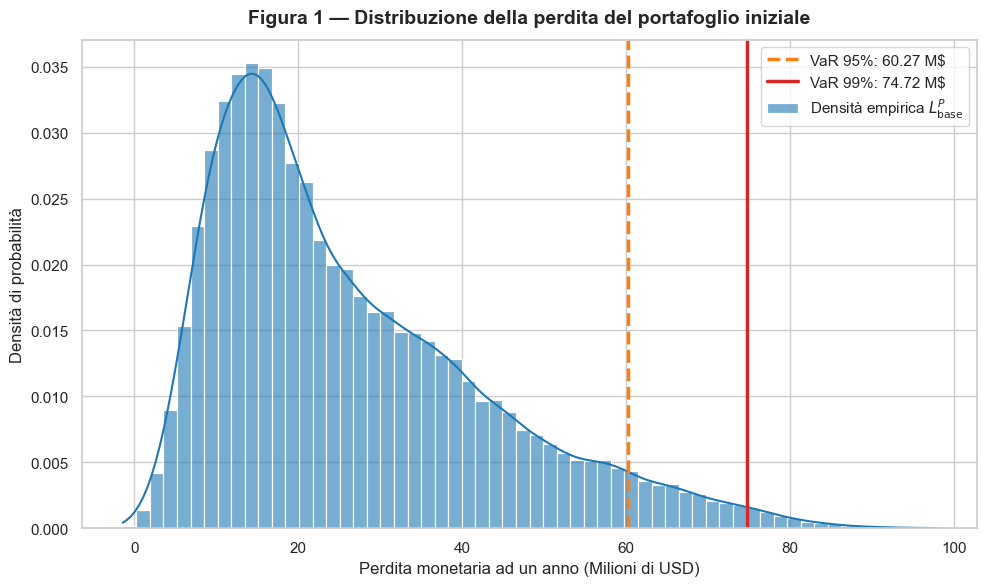

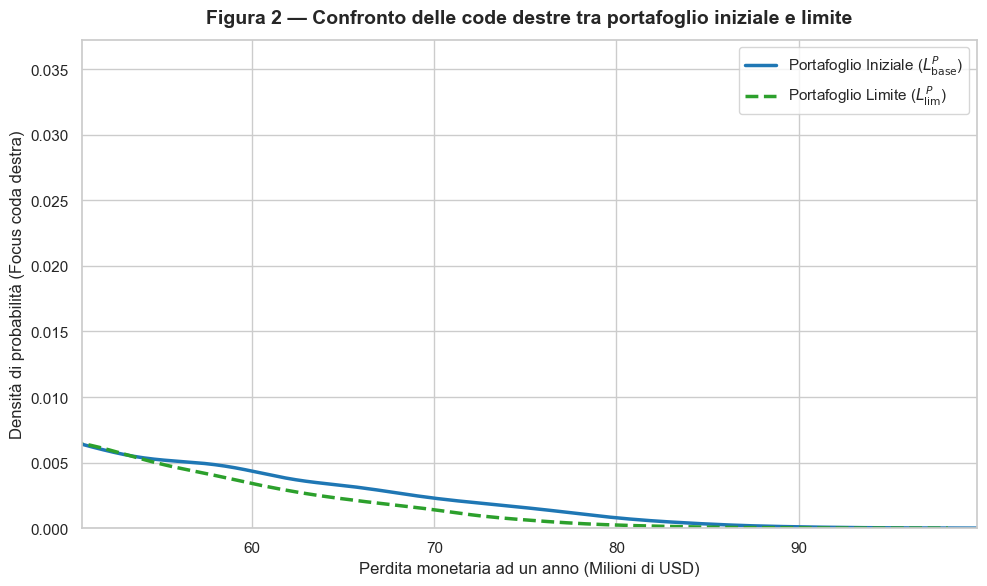

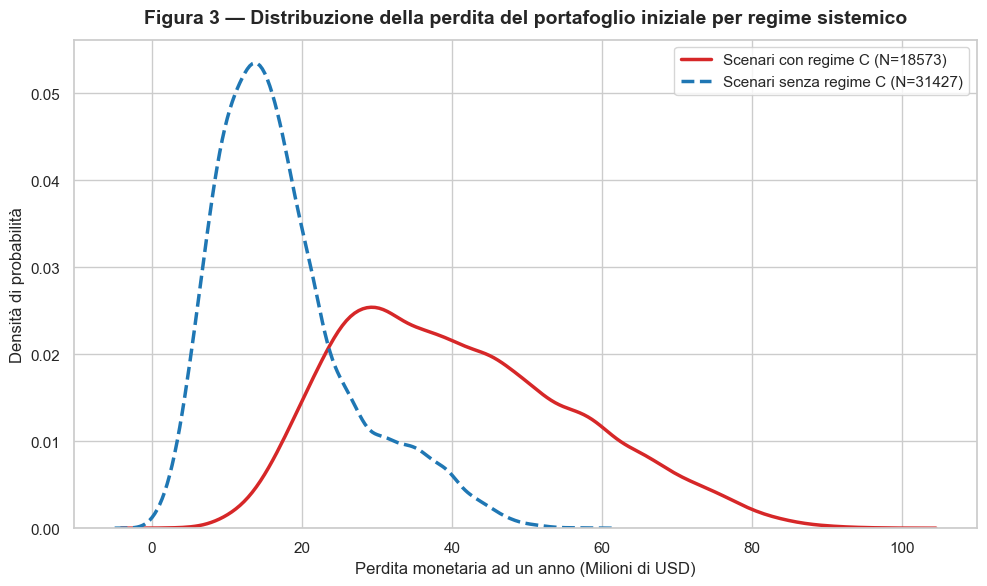

=== REPORT FINALE SUI 17 CONTROLLI DI VALIDAZIONE ===
      Codice                                                 Descrizione Controllo  Esito
 Controllo 1                                              Righe di Q sommano a 1.0   True
 Controllo 2                               Righe delle matrici P^(m) sommano a 1.0   True
 Controllo 3                  Stato D assorbente in tutte le matrici di migrazione   True
 Controllo 4                                     Regime sistemico iniziale M_0 = S   True
 Controllo 5                        Unica traiettoria sistemica comune per replica   True
 Controllo 6                   Migrazioni indipendenti condizionatamente al regime   True
 Controllo 7                          Tempo tau_i coincide col primo ingresso in D   True
 Controllo 8                         LGD applicata basata sul regime M_(tau_i - 1)   True
 Controllo 9                                 Assorbimento permanente nello stato D   True
Controllo 10                           Matrice

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazione dello stile grafico per i report
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# ==========================================
# 1. FIGURA 1 — DISTRIBUZIONE PERDITA PORTAFOGLIO INIZIALE
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    L_base_P, 
    bins=60, 
    kde=True, 
    color='#1f77b4', 
    stat='density', 
    ax=ax, 
    alpha=0.6,
    label='Densità empirica $L_{\\mathrm{base}}^P$'
)

# Linee verticali per VaR 95% e VaR 99%
var95_val = metrics_base['VaR_95']
var99_val = metrics_base['VaR_99']

ax.axvline(var95_val, color='#ff7f0e', linestyle='--', linewidth=2.5, label=f'VaR 95%: {var95_val:.2f} M$')
ax.axvline(var99_val, color='#d62728', linestyle='-', linewidth=2.5, label=f'VaR 99%: {var99_val:.2f} M$')

ax.set_title("Figura 1 — Distribuzione della perdita del portafoglio iniziale", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Perdita monetaria ad un anno (Milioni di USD)", fontsize=12)
ax.set_ylabel("Densità di probabilità", fontsize=12)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. FIGURA 2 — CONFRONTO DELLE CODE DESTRE
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot sovrapposto delle densita' per entrambi i portafogli
sns.kdeplot(
    L_base_P, 
    color='#1f77b4', 
    linewidth=2.5, 
    ax=ax, 
    label='Portafoglio Iniziale ($L_{\\mathrm{base}}^P$)'
)
sns.kdeplot(
    L_lim_P, 
    color='#2ca02c', 
    linewidth=2.5, 
    linestyle='--', 
    ax=ax, 
    label='Portafoglio Limite ($L_{\\mathrm{lim}}^P$)'
)

# Zoom sulla coda destra (dal VaR 90% del portafoglio base in poi)
tail_threshold = np.percentile(L_base_P, 90)
ax.set_xlim(left=tail_threshold, right=max(L_base_P.max(), L_lim_P.max()) * 1.02)

ax.set_title("Figura 2 — Confronto delle code destre tra portafoglio iniziale e limite", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Perdita monetaria ad un anno (Milioni di USD)", fontsize=12)
ax.set_ylabel("Densità di probabilità (Focus coda destra)", fontsize=12)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# ==========================================
# 3. FIGURA 3 — REGIME SISTEMICO E PERDITA
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(
    L_base_P[has_regime_C], 
    color='#d62728', 
    linewidth=2.5, 
    ax=ax, 
    label=f'Scenari con regime C (N={n_crisis_scenarios})'
)
sns.kdeplot(
    L_base_P[~has_regime_C], 
    color='#1f77b4', 
    linewidth=2.5, 
    linestyle='--', 
    ax=ax, 
    label=f'Scenari senza regime C (N={N_MC - n_crisis_scenarios})'
)

ax.set_title("Figura 3 — Distribuzione della perdita del portafoglio iniziale per regime sistemico", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Perdita monetaria ad un anno (Milioni di USD)", fontsize=12)
ax.set_ylabel("Densità di probabilità", fontsize=12)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. REPORT SINTETICO DEI CONTROLLI DI VALIDAZIONE
# ==========================================
all_controls = [
    ("Controllo 1", "Righe di Q sommano a 1.0", ctrl_1),
    ("Controllo 2", "Righe delle matrici P^(m) sommano a 1.0", ctrl_2),
    ("Controllo 3", "Stato D assorbente in tutte le matrici di migrazione", ctrl_3),
    ("Controllo 4", "Regime sistemico iniziale M_0 = S", ctrl_4),
    ("Controllo 5", "Unica traiettoria sistemica comune per replica", ctrl_5),
    ("Controllo 6", "Migrazioni indipendenti condizionatamente al regime", ctrl_6),
    ("Controllo 7", "Tempo tau_i coincide col primo ingresso in D", ctrl_7),
    ("Controllo 8", "LGD applicata basata sul regime M_(tau_i - 1)", ctrl_8),
    ("Controllo 9", "Assorbimento permanente nello stato D", ctrl_9),
    ("Controllo 10", "Matrice l_matrix applicata solo a tau_i > 4", ctrl_10),
    ("Controllo 11", "Investimento complessivo = 200M$ in entrambi i portafogli", ctrl_11),
    ("Controllo 12", "Politica di concentrazione (Evergrande 20M$, 10M$ a BBB/BB)", ctrl_12),
    ("Controllo 13", "Common Random Numbers per il confronto tra portafogli", ctrl_13),
    ("Controllo 14", "Perdita aggregata = somma delle perdite individuali", ctrl_14),
    ("Controllo 15", "Riproducibilità esatta via seed 2027", ctrl_15),
    ("Controllo 16", "Stabilità stime Monte Carlo all'aumentare delle simulazioni", ctrl_16),
    ("Controllo 17", "VaR e CVaR calcolati su perdite monetarie con ordine di coda coerente", ctrl_17)
]

df_controls_report = pd.DataFrame(all_controls, columns=["Codice", "Descrizione Controllo", "Esito"])

print("=== REPORT FINALE SUI 17 CONTROLLI DI VALIDAZIONE ===")
print(df_controls_report.to_string(index=False))

all_passed = all(ctrl[2] for ctrl in all_controls)
print(f"\n>>> ESITO GLOBALE VALIDAZIONE: {'TUTTI I CONTROLLI SUPERATI CON SUCCESSO' if all_passed else 'ATTENZIONE: CONTROLLI FALLITI'}")